# Chapter 23: System Dynamics with DisSModel

*Part IV — DisSModel: Core and Paradigms*

Implemented by the [`dissmodel-sysdyn`](https://github.com/DisSModel/dissmodel-sysdyn) package.

> **Live demo:** every model in this chapter is also runnable directly in the browser, no installation required — [dissmodel-sysdyn-demo on Hugging Face Spaces](https://huggingface.co/spaces/profsergiocosta/dissmodel-sysdyn-demo).

## Learning Objectives

By the end of this chapter you will be able to:

- Install and explore the `dissmodel-sysdyn` model library
- Understand stocks, flows, and feedback loops
- Recognize the categories of available system dynamics models
- Compare a TerraME Lua model against its DisSModel equivalent, term for term

In [1]:
# Standard imports — add chapter-specific imports below
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Every model in Chapters 21 and 22 kept its state in a `gdf` or a `backend` — geometry mattered. System dynamics models don't have geometry at all: a population, a temperature, a susceptible/infected/recovered split are just numbers, changing over time according to equations, with no coordinate attached to any of them. `dissmodel-sysdyn`'s models subclass `dissmodel.core.Model` directly — no `SpatialModel`, no `RasterModel` — proof that the lifecycle Chapter 21 introduced (`setup → execute`, driven by `Environment.run()`) was never really about space in the first place.

## Installation and Included Models

`dissmodel-sysdyn` isn't on PyPI yet, so it installs the same way every other extension package has since Chapter 22:

```bash
pip install "git+https://github.com/DisSModel/dissmodel-sysdyn.git"
```

The package ships fourteen models, grouped by the phenomenon they model rather than by any technical distinction:

| Category | Models |
|---|---|
| Epidemiology | SIR |
| Ecology & Biology | Predator-Prey (Lotka-Volterra), Yeast Growth, Daisyworld, Population Growth, Limited Growth, Chaotic Growth |
| Physics & Thermodynamics | Coffee Cooling, Room Temperature, Tub (Stock/Flow) |
| Complex Systems | Lorenz Attractor, Homeostasis |
| Environment | Mono Lake Water Balance |
| Stochasticity | Random Walk |

Every one of them is runnable the same three ways Chapter 22 introduced for `dissmodel-ca`:

```bash
python examples/cli/sysdyn_sir.py
streamlit run examples/streamlit/sysdyn_all.py
jupyter notebook examples/notebooks/
```

The fourteen notebooks are this package's real teaching surface — each pairs a scientific framing (epidemiology, ecology, thermodynamics, deterministic chaos) with the exact equations implemented in `src/dissmodel_sysdyn/models/`, going well beyond what fits in this one chapter.

## Theory: Stocks and Flows

Modeling a system means deciding which measurable parts of reality it has, and how they affect each other. System Dynamics (Meadows, 2008) reduces every such part to one of two kinds of element:

- **Stock** — a measurable quantity that has accumulated by a given moment: water in a tub, a population count, a temperature.
- **Flow** — the *rate of change* of a stock: what comes in (inflow), what goes out (outflow).

$$\text{stock}(t) = \text{stock}(t - dt) + \text{inflow} \cdot dt - \text{outflow} \cdot dt$$

Three consequences follow directly, and they shape every model in this chapter:

1. There are exactly two ways to increase a stock — raise the inflow, or lower the outflow.
2. Stocks act as delays or buffers: they don't react instantaneously to a flow change, which is what gives a system *inertia*.
3. Stocks decouple inflow from outflow — a tub can be filling and draining at the same moment; the stock only ever records the net balance of two independent forces.

### Tub: TerraME vs DisSModel

TerraME's `Tub.lua` needed an explicit `Timer`, with the periodic inflow modeled as a second, separately-scheduled `Event`. `dissmodel_sysdyn.models.tub.Tub` reaches the identical behavior with no `Timer` at all — `Environment` already calls `execute()` every tick, so the periodic inflow becomes nothing more than a step counter checked with `%`:

```lua
-- Tub.lua (TerraME)
Tub = Model{
	water = 40,
	outFlow = 5,
	inFlow = 0,
	finalTime = 8,
	execute = function(model)
		model.water = model.water - model.outFlow

		if model.water < 0 then
			model.water = 0
		end
	end,
	init = function (model)
		model.chart = Chart{target = model, select = "water"}

		model.timer = Timer{
			Event{action = model},
			Event{start = 10, period = 10, action = function()
				model.water = model.water + model.inFlow
			end},
			Event{action = model.chart}
		}
	end
}
```

In [2]:
from dissmodel.core import Environment
from dissmodel_sysdyn.models import Tub

env = Environment(start_time=0, end_time=20)
tub = Tub(water=40.0, out_flow=5.0, in_flow=30.0, in_period=10)
env.run()
print("Water remaining after 20 ticks:", tub.water)

Running from 0 to 20 (duration: 20)
Water remaining after 20 ticks: 10.0


The business logic carries over line for line — draining every tick, refilling every `in_period` ticks, clamped at zero. What disappears entirely is TerraME's `Timer`/`Event` scaffolding: DisSModel's implicit `setup()` → `execute()` cycle absorbs it, the same simplification Chapter 21's `Ticker` example demonstrated on a toy.

## Feedbacks: Balancing and Reinforcing

A feedback is how a system affects itself — part of an outflow loops back to influence an inflow, closing a causal loop. Because the effect always takes one `dt` to propagate, a feedback can only shape the *next* step, never the current one.

**Balancing** (negative, self-correcting) feedback is goal-seeking: the system moves toward a reference value and settles there. Coffee cooling toward room temperature is the canonical example — the rate of heat loss is proportional to how far the coffee still is from equilibrium, so it converges whether it starts hotter or colder than the room.

**Reinforcing** (positive, self-amplifying) feedback has no such ceiling built into the equation itself — it amplifies deviations rather than correcting them, exactly how unconstrained population growth behaves. Every reinforcing feedback in the real world eventually meets a limit from somewhere else — resources, space, or a balancing feedback stepping in — nothing grows exponentially forever.

### Coffee: TerraME vs DisSModel

Newton's law of cooling, reproduced term for term — only the Lua constant `0.1` becomes a named, Streamlit-exposable `cooling_rate` parameter:

```lua
-- Coffee.lua (TerraME)
Coffee = Model{
	temperature     = 80,
	roomTemperature = 20,
	finalTime       = 20,
	execute = function(model)
		local difference = model.temperature - model.roomTemperature
		model.temperature =  model.temperature - difference * 0.1
	end,
	init = function(model)
		model.chart = Chart{target = model, select = {"temperature"}}
		model.timer = Timer{Event{action = model}, Event{action = model.chart}}
	end
}
```

In [3]:
from dissmodel_sysdyn.models import Coffee

env = Environment(start_time=0, end_time=20)
coffee = Coffee(temperature=80.0, room_temperature=20.0, cooling_rate=0.1)
env.run()
print(f"Coffee temperature after 20 ticks: {coffee.temperature:.1f}°C")

Running from 0 to 20 (duration: 20)
Coffee temperature after 20 ticks: 26.6°C


## Epidemiology: The SIR Model

`SIR` splits a population into three stocks that transform into one another: **S**usceptible → **I**nfected → **R**ecovered. The transition rate depends on how long an infection lasts, how many contacts an infected individual has per tick, and what fraction of those contacts are with someone still susceptible:

```lua
-- SIR.lua (TerraME)
SIR = Model{
	susceptible = 9998,
	infected = 2,
	recovered = 0,
	duration = 2,
	finalTime = 30,
	contacts = 6,
	maximum = math.huge,
	probability = 0.25,
	init = function(model)
		model.chart = Chart{
			target = model,
			select = {"susceptible", "infected", "recovered"},
			color = {"green", "red", "blue"}
		}
		model.maxInfected = model.infected
		model.finalInfected = {model.infected}

		model.timer = Timer{
			Event{action = function()
				local proportion = model.susceptible /
					(model.susceptible + model.infected + model.recovered)
				local newInfected = model.infected * model.contacts * model.probability * proportion
				local newRecovered = model.infected / model.duration

				model.susceptible = model.susceptible - newInfected
				model.recovered = model.recovered + newRecovered
				model.infected = model.infected + newInfected - newRecovered

				if model.maxInfected < model.infected then
					model.maxInfected = model.infected
				end
				table.insert(model.finalInfected, model.infected)
			end},
			-- educational-campaign feedback: not carried over into dissmodel_sysdyn.models.sir.SIR
			Event{action = function()
				if model.infected >= model.maximum then
					model.contacts = model.contacts / 2
					return false
				end
			end},
			Event{action = model.chart}
		}
	end
}
```

In [4]:
from dissmodel_sysdyn.models import SIR

env = Environment(start_time=0, end_time=20)
sir = SIR(susceptible=9998, infected=2, recovered=0, duration=2, contacts=6, probability=0.25)
env.run()
print(f"S={sir.susceptible:.0f}  I={sir.infected:.0f}  R={sir.recovered:.0f}")

Running from 0 to 20 (duration: 20)
S=252  I=43  R=9705


Every model in `dissmodel-sysdyn` is already decorated with `@track_plot` per stock — `SIR` tracks `Susceptible`, `Infected`, and `Recovered` this way — which is what lets a `Chart` component render them live with no extra wiring on your part. Attach one the same way `Map` attached itself to a grid in Chapter 21: construct it, then `env.run()`:

In [5]:
from dissmodel.visualization import Chart

env = Environment(start_time=0, end_time=20)
sir = SIR(susceptible=9998, infected=2, recovered=0, duration=2, contacts=6, probability=0.25)
Chart(show_legend=True, show_grid=True, title="SIR Model")

env.run()

Output()

Running from 0 to 20 (duration: 20)


`Chart` needed no reference to `sir` at all — it discovers every `@track_plot`-decorated attribute from whatever models are registered in the active `Environment` and plots all of them automatically, live, one frame per tick. That's the same automatic-discovery spirit Chapter 22's Streamlit example used to turn every `CellularAutomaton` subclass into a UI control without listing them by hand.

<div class="admonition warning">
<p class="admonition-title">Watch out</p>
<p>The original TerraME <code>SIR.lua</code> had a second behavior not carried over into <code>dissmodel-sysdyn</code>'s <code>sir.py</code>: an educational campaign that cuts <code>contacts</code> in half once infections cross a threshold. If your own model needs that branch, it has to be added to <code>execute()</code> by hand — it is a known, documented gap, not an oversight to work around silently.</p>
</div>

## Chaos and Sensitivity to Initial Conditions

Edward Lorenz discovered deterministic chaos by accident in 1961, re-running a weather simulation with a rounded input (`0.506` instead of `0.506127`) and watching the result diverge completely within a handful of steps. Chaos needs three ingredients together: **high sensitivity to initial conditions** (small differences grow exponentially rather than staying small), **non-linearity** (no non-linear term in the equations, no chaos), and **determinism** — the same exact state always produces the same future, yet remains unpredictable in practice, because no initial condition is ever known with infinite precision.

`ChaoticGrowth` is the logistic map in its simplest form:

$$\text{growth}(t) = r \cdot \text{growth}(t-dt) \cdot (1 - \text{growth}(t-dt))$$

`Lorenz` is the three-equation convection system behind the "butterfly" attractor:

$$\frac{dx}{dt} = \sigma(y - x) \qquad \frac{dy}{dt} = x(\rho - z) - y \qquad \frac{dz}{dt} = xy - \beta z$$

```lua
-- ChaoticGrowth.lua (TerraME)
ChaoticGrowth = Model{
	pop       = 0.10,
	rate      = 4.0,
	finalTime = 300,
	execute = function(model)
		model.pop = model.rate * model.pop * (1 - model.pop)
	end,
	init = function(model)
		model.chart = Chart{target = model, select = "pop"}
		model.timer = Timer{Event{action = model}, Event{action = model.chart}}
	end
}
```

```lua
-- Lorenz.lua (TerraME)
Lorenz = Model{
	x = 1.0, y = 1.0, z = 1.0,
	delta = 0.01,
	rho   = 28.0,
	sigma = 10.0,
	beta  = 8.0 / 3.0,
	finalTime = 10000,
	init = function(model)
		model.chart1 = Chart{target = model, select = "y"}
		model.chart2 = Chart{target = model, select = "z", xAxis = "y"}

		model.timer = Timer{
			Event{action = function()
				local nx = model.sigma * (model.y - model.x)
				local ny = model.x * (model.rho - model.z) - model.y
				local nz = model.x * model.y - model.beta * model.z

				model.x = model.x + model.delta * nx
				model.y = model.y + model.delta * ny
				model.z = model.z + model.delta * nz
			end},
			Event{action = model.chart1},
			Event{action = model.chart2}
		}
	end
}
```

In [6]:
from dissmodel_sysdyn.models import ChaoticGrowth, Lorenz

env = Environment(start_time=0, end_time=30)
cg = ChaoticGrowth(rate=4.0)
env.run()
print("ChaoticGrowth final value:", cg.pop)

env = Environment(start_time=0, end_time=30)
lz = Lorenz()
env.run()
print(f"Lorenz final state: x={lz.x:.2f}, y={lz.y:.2f}, z={lz.z:.2f}")

Running from 0 to 30 (duration: 30)
ChaoticGrowth final value: 0.8708926951105607
Running from 0 to 30 (duration: 30)
Lorenz final state: x=16.72, y=28.65, z=24.52


Both models keep their original TerraME default parameters exactly (`rate=4.0` for the logistic map; `sigma=10, rho=28, beta=8/3` for Lorenz's classic butterfly regime) — a deliberate choice that keeps the DisSModel version numerically comparable to decades of published TerraME results using the same constants.

## Predator-Prey and Phase-Plane Analysis

The Lotka-Volterra model formalizes two rules — prey mostly die by predation, and predator survival depends on prey availability — plus one mathematical assumption: the two species meet at a rate proportional to *both* populations at once:

$$\frac{dx}{dt} = rx - axy \qquad \frac{dy}{dt} = eaxy - my$$

```lua
-- PredatorPrey.lua (TerraME)
PredatorPrey = Model{
	predator        = Choice{min = 1, default = 40},
	prey            = Choice{min = 1, default = 1000},
	preyGrowth      = Choice{min = 0.000001, max = 1,   default = 0.08},
	preyDeathPred   = Choice{min = 0.000001, max = 0.5, default = 0.001},
	predDeath       = Choice{min = 0.000001, max = 0.5, default = 0.02},
	predGrowthKills = Choice{min = 0,        max = 0.5, default = 0.00002},
	finalTime       = Choice{min = 5, default = 500},
	execute = function(model)
		model.prey = model.prey + model.preyGrowth * model.prey
		                - model.preyDeathPred * model.prey * model.predator
		model.predator = model.predator - model.predDeath * model.predator
		              + model.predGrowthKills * model.prey * model.predator
	end,
	init = function(model)
		model.chart1 = Chart{target = model, select = {"prey", "predator"}}
		model.chart2 = Chart{target = model, select = "predator", xAxis = "prey"}
		model.timer = Timer{
			Event{action = model, period = model.period},
			Event{action = model.chart1},
			Event{action = model.chart2}
		}
	end
}
```

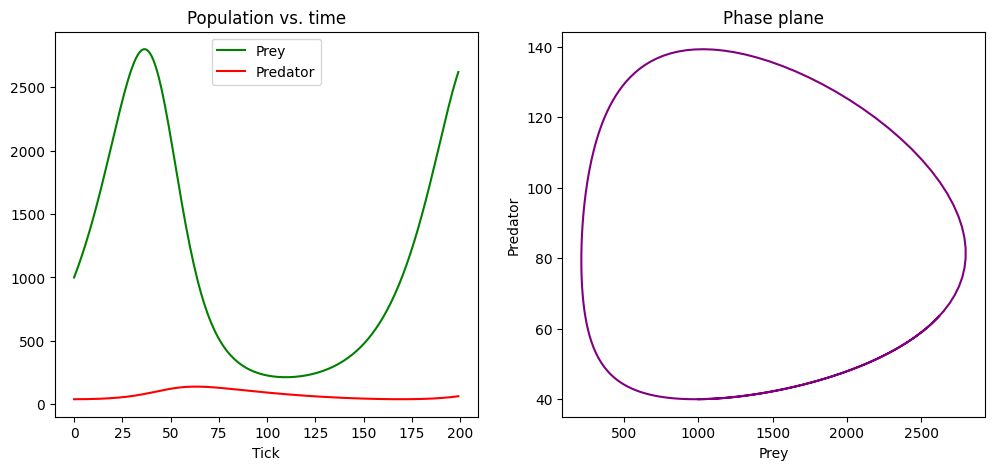

In [7]:
from dissmodel_sysdyn.models import PredatorPrey

env = Environment(start_time=0, end_time=200)
pp = PredatorPrey(
    predator=40.0, prey=1000.0,
    prey_growth=0.08, prey_death_pred=0.001,
    pred_death=0.02, pred_growth_kills=0.00002,
)
prey_history, predator_history = [], []
for _ in range(200):
    prey_history.append(pp.prey)
    predator_history.append(pp.predator)
    pp.execute()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(prey_history, label="Prey", color="green")
axes[0].plot(predator_history, label="Predator", color="red")
axes[0].set_xlabel("Tick")
axes[0].legend()
axes[0].set_title("Population vs. time")

axes[1].plot(prey_history, predator_history, color="purple")
axes[1].set_xlabel("Prey")
axes[1].set_ylabel("Predator")
axes[1].set_title("Phase plane")
plt.show()

Besides the usual population-vs-time chart, this system has a second, more revealing view: the **phase plane** — one population plotted against the other, time itself invisible. In Lotka-Volterra the resulting trajectory is a closed loop, and the point sitting inside every loop is the **equilibrium** — `prey=1000, predator=40` for these classic parameters — the one stationary state where neither population changes. `@track_plot`, the decorator every model in this package uses to feed its own live Streamlit chart, only produces time-series views; a phase-plane plot like the one above has to be assembled by hand from tracked history, exactly as the cell above does by calling `execute()` directly rather than through `env.run()`.

## Daisyworld and the Gaia Hypothesis

James Lovelock, analyzing the Martian atmosphere at NASA, asked why Earth's surface temperature has stayed within a narrow range for 3.6 billion years while solar output rose roughly 25% over that time. His answer — the Gaia hypothesis — is that the biosphere maintains a homeostatic feedback loop with the atmosphere: biological factors regulate physical ones, which in turn constrain what's biologically possible. No intent is required, only feedback.

`Daisyworld` is the minimal model of that idea: black daisies (low albedo, warm the planet) and white daisies (high albedo, cool it) compete for bare ground. When the planet runs cold, black daisies get an edge and warm it; when it runs hot, white daisies get the edge and cool it — the net result is a planet whose temperature stays close to the daisies' own optimum across a wide range of solar input, with no central controller anywhere in the equations:

```lua
-- Daisyworld.lua (TerraME) -- helper functions above the model definition
local SIGMA = 5.67E-08        -- Stefan-Boltzmann constant
local SOLAR_FLUX = 3668       -- Watts/square meter
local HEAT_TRANSFER_COEF = 2.06E09

local function daisyGrowthRate(tempK)
	local gr = 0.0
	local temp = tempK - 273
	if temp > 5.0 and temp < 40.0 then
		gr = 1 - 0.003265 * (22.5 - temp)^2
	end
	return gr
end

local function calcTemp(lum, albedo)
	return (lum * SOLAR_FLUX * (1 - albedo) / (4 * SIGMA)) ^ 0.25
end

local function tempNearDaisy(planet_temp, planet_albedo, daisy_albedo)
	return (HEAT_TRANSFER_COEF * (planet_albedo - daisy_albedo) + planet_temp ^ 4) ^ 0.25
end

Daisyworld = Model{
	sunLuminosity = 0.7,
	planetArea = 1.0, whiteArea = 0.40, blackArea = 0.273, emptyArea = 0.327,
	whiteAlbedo = 0.75, blackAlbedo = 0.25, soilAlbedo = 0.50,
	decayRate = 0.3,
	finalTime = 100,
	-- ...init() wires calcTemp/tempNearDaisy/daisyGrowthRate into a Timer, one Event per tick
}
```

In [8]:
from dissmodel_sysdyn.models import Daisyworld

env = Environment(start_time=0, end_time=50)
world = Daisyworld(sun_luminosity=0.7, white_area=0.4, black_area=0.273, empty_area=0.327)
env.run()
print(f"White: {world.white_area:.3f}  Black: {world.black_area:.3f}  Empty: {world.empty_area:.3f}")

Running from 0 to 50 (duration: 50)
White: 0.000  Black: 0.697  Empty: 0.302


The physical constants underneath this — the Stefan-Boltzmann constant, solar flux, the heat-transfer coefficient, and the specific quadratic shape of the daisy growth-rate curve — were all preserved exactly from the original TerraME model, down to its "magic number" coefficients. Numerical fidelity to a decades-old reference implementation is exactly the kind of validation Chapter 21's `ModelExecutor` section argued matters: a reproduction that silently drifts from its reference isn't a reproduction.

## Exercises

1. **Why no substrate?** Open the source for `SIR` (or any model in this chapter) and confirm it extends `dissmodel.core.Model` directly, not `SpatialModel`. In your own words, explain why a system-dynamics model has no use for a `gdf`, a `backend`, or a neighborhood.
2. **Which compartment peaks first?** Run the SIR example with a much shorter `duration` (try `duration=1`) and a longer one (`duration=5`), holding everything else fixed. Which parameter controls how quickly `infected` peaks, and why?
3. **Two kinds of `execute()`.** Compare `SIR.execute()` (three coupled stocks, each a running total) to `Lorenz.execute()` (three coupled rates of change). Both override `execute()` on a plain `Model` and use neither `pre_execute()` nor `post_execute()` — why not?
4. **A feedback of your own.** Sketch, in a sentence, a real-world system with a *reinforcing* feedback you've personally observed (not one already covered in this chapter), and identify what eventually limits it in practice.

In [9]:
# Your code here

## Summary

### Key concepts introduced

- Stocks and flows: a stock accumulates, a flow is its rate of change, and every model in this chapter is built from that one relationship
- Balancing (self-correcting) versus reinforcing (self-amplifying) feedback, and why every reinforcing feedback meets a limit somewhere in the real world
- `dissmodel-sysdyn` models subclass `Model` directly — proof the Chapter 21 lifecycle was never inherently spatial
- Six TerraME-to-DisSModel comparisons (`Tub`, `Coffee`, `SIR`, `ChaoticGrowth`/`Lorenz`, `PredatorPrey`, `Daisyworld`), each preserving the original equations and default parameters exactly, with only the `Timer`/`Event` scaffolding disappearing into `Environment.run()`
- The phase plane as a second way to visualize a coupled system, orthogonal to the time-series view `@track_plot` produces automatically
- A documented gap (SIR's educational-campaign branch) as an example of honest scope-limiting rather than silent omission

Chapter 24 returns to spatial models properly, going well beyond Chapter 21's Game of Life teaser into the full `dissmodel-ca` library.

## Further Reading

- Meadows, D. H. (2008). *Thinking in Systems: A Primer*. Chelsea Green Publishing — the standard reference for stock-and-flow thinking
- Lorenz, E. N. (1963). "Deterministic Nonperiodic Flow." *Journal of the Atmospheric Sciences*, 20(2), 130-141 — the original chaos paper
- Watson, A. J., & Lovelock, J. E. (1983). "Biological homeostasis of the global environment: the parable of Daisyworld." *Tellus B*, 35(4), 284-289
- dissmodel-sysdyn on GitHub: <https://github.com/DisSModel/dissmodel-sysdyn>
- TerraME/sysdyn on GitHub — source for every Lua model compared in this chapter (`Tub.lua`, `Coffee.lua`, `SIR.lua`, `ChaoticGrowth.lua`, `Lorenz.lua`, `PredatorPrey.lua`, `Daisyworld.lua`): <https://github.com/TerraME/sysdyn>
- Live demo (no installation required): <https://huggingface.co/spaces/profsergiocosta/dissmodel-sysdyn-demo>